In [89]:
#라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

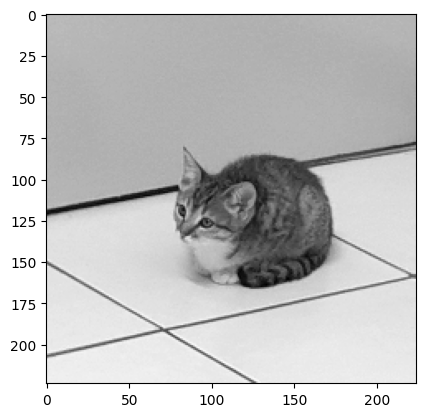

In [90]:
#이미지 불러오기 (흑백)
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224, 224)) 
#224x224로 리사이즈 (필터링 결과를 선명하게 보기 위해 사이즈를 줄임임)
plt.imshow(img, cmap="gray")

In [91]:
# Salt & Pepper Noise 추가 함수
# random함수로 랜덤한 부분에 노이즈 추가
def add_salt_pepper_noise(image):
    img_noise = image.copy()
    num_pepper = int(0.1 * image.size) # 10%
    num_salt = int(0.1 * image.size) # 10%
    
    # Pepper (0)
    for _ in range(num_pepper):
        i = random.randint(0, image.shape[0] - 1)
        j = random.randint(0, image.shape[1] - 1)
        img_noise[i, j] = 0

    # Salt (255)
    for _ in range(num_salt):
        i = random.randint(0, image.shape[0] - 1)
        j = random.randint(0, image.shape[1] - 1)
        img_noise[i, j] = 255

    return img_noise

In [92]:
def mean_kernel(kernel_size):
    #kernel_size x kernel_size 평균 필터 생성
    return np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size * kernel_size)
# 1 로 채워진 NxN 커널 / 커널 사이즈 * 커널 사이즈

In [93]:
# FFT 기반 컨벌루션 함수
# 컨볼루션은 많은 연산이 필요하기 때문에 푸리에 변환을 이용용
# 이미지, 커널을 전부 푸리에 변환으로 주파수 영역으로 바꿈
# 이후, 주파수 영역에서의 곱샘 진행
# 역 푸리에 변환 
def fft_convolution(img, kernel):
    H, W = img.shape
    KH, KW = kernel.shape

    # 이미지와 커널을 zero-padding, 선형 컨벌루션을 위함함
    pad_H = H + KH - 1
    pad_W = W + KW - 1

    padded_img = np.zeros((pad_H, pad_W)) #0으로 채워진 이미지 생성
    padded_img[:H, :W] = img # 원본 이미지 삽입

    padded_kernel = np.zeros((pad_H, pad_W))
    padded_kernel[:KH, :KW] = kernel
    # 이미지와 커널이 같은 크기로 만들어야 주파수 영역에서 곱셈 가능

    # FFT 수행 (중심 이동 포함)
    fft_img = np.fft.fftshift(np.fft.fft2(padded_img)) #2차원 푸리에 변환
    fft_kernel = np.fft.fftshift(np.fft.fft2(padded_kernel)) #주파수의 중심을 중앙으로 이동동

    # 주파수 영역에서 곱하기
    fft_product = fft_img * fft_kernel

    # 역 FFT 수행
    ifft_shift = np.fft.ifftshift(fft_product) #주파수의 중심을 원래 위치로 이동
    conv_result = np.fft.ifft2(ifft_shift) #2차원 역 푸리에 변환
    conv_result = np.real(conv_result) #실수부만 추출(소수점 오차로 인한 복소수 제거)

    start_H = KH // 2 # 필터로 인해 생긴 여백 제거
    start_W = KW // 2
    result = conv_result[start_H:start_H + H, start_W:start_W + W]

    return result

In [ ]:
def median_filter(img, kernel_size=(3,3), stride=1):
    # stride : 필터를 얼마나 간격을 두고 적용할 것인지
    H, W = img.shape
    KH, KW = kernel_size

    # zero-padding 사용하니까 결과 이미지의 색상이 전체적으로 연해짐
    # 이는 가장자리에 0, 가장 밝은 값이 있어 전체적인 median 값이 낮아짐
    # 이를 위해 edge-padding 사용함(가장자리 픽셀의 값으로 채움)
    pad_h = KH // 2
    pad_w = KW // 2

    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')  # 엣지 값 복사 padding

    # 2. 결과 이미지 생성
    result = np.zeros_like(img)

    # 3. 중간값 필터 적용
    for i in range(0, H, stride):
        for j in range(0, W, stride):
            window = padded_img[i:i+KH, j:j+KW]
            result[i, j] = np.median(window)

    return result.astype(np.uint8) # 계산 결과가 float 형태라 형변환 진행


In [95]:
# 5. 노이즈 추가
img_noise = add_salt_pepper_noise(img)
# 6. 필터 적용
kernel = mean_kernel(kernel_size=3)
filtered_img = fft_convolution(img, kernel)
median_filtered = median_filter(img_noise, kernel_size=(3, 3))

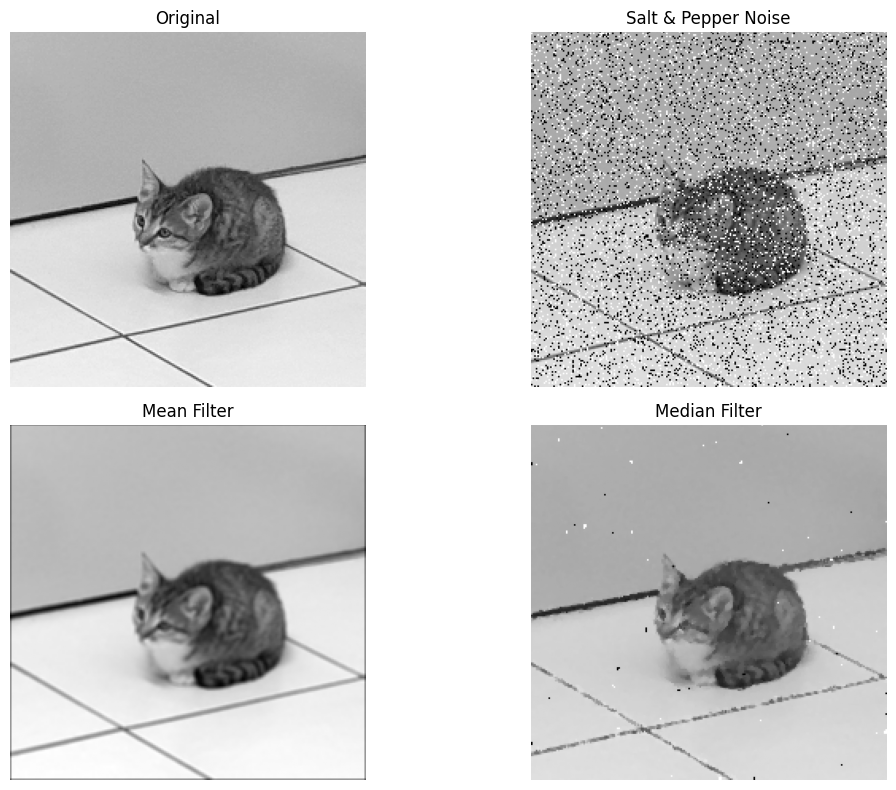

In [96]:
# 7. 결과 시각화
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_noise, cmap='gray')
plt.title("Salt & Pepper Noise")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(filtered_img, cmap='gray')
plt.title("Mean Filter")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filter")
plt.axis('off')

plt.tight_layout()
plt.show()